Dataset Shape: (1000, 9)

First 5 Rows:
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  

Numerical Features:
['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

Categor

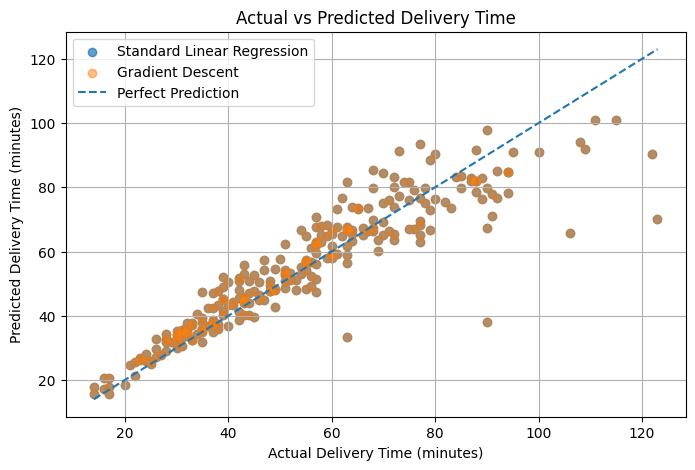

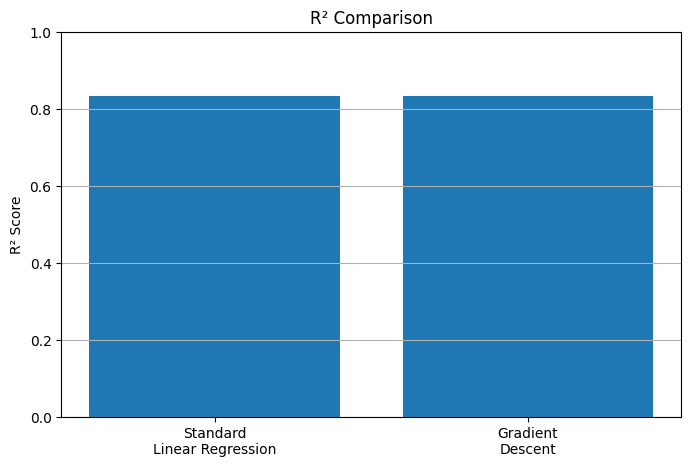

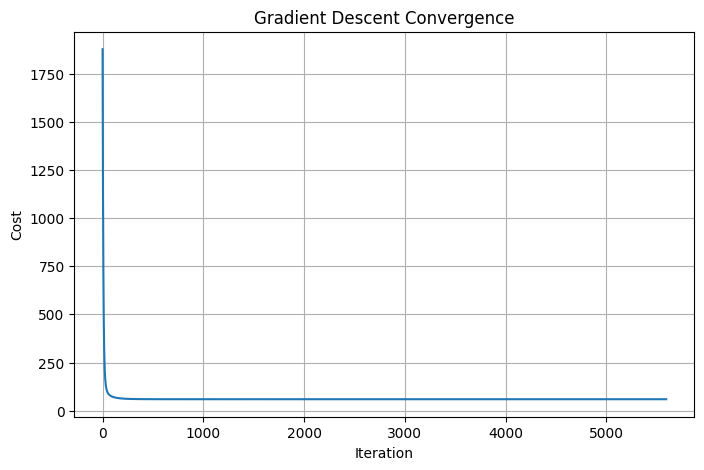


CONCLUSION
Both methods produced very similar performance. This shows that Gradient Descent successfully learned the parameters of the Linear Regression model.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



# 1. LOAD DATASET


df = pd.read_csv("Food_Delivery_Times.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


# 2. SEPARATE FEATURES AND TARGET

# Remove ID because it does not help predict delivery time
X = df.drop(columns=["Delivery_Time_min", "Order_ID"])
y = df["Delivery_Time_min"]


# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# 3. TRAIN-TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))



# 4. PREPROCESSING


# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])


# 5. LINEAR REGRESSION WITHOUT MANUAL GRADIENT DESCENT


print("\n" + "="*60)
print("MODEL 1: STANDARD LINEAR REGRESSION")
print("="*60)

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train
linear_model.fit(X_train, y_train)

# Predict
y_pred_lr = linear_model.predict(X_test)

# Metrics
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("\nStandard Linear Regression Results:")
print(f"R² Score : {lr_r2:.4f}")
print(f"MAE      : {lr_mae:.4f} minutes")
print(f"RMSE     : {lr_rmse:.4f} minutes")



# 6. PREPROCESS DATA FOR GRADIENT DESCENT

# Gradient Descent works better with scaled numerical data
gd_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

gd_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

gd_preprocessor = ColumnTransformer([
    ("num", gd_numeric_transformer, numerical_features),
    ("cat", gd_categorical_transformer, categorical_features)
])

# Transform training and testing data
X_train_gd = gd_preprocessor.fit_transform(X_train)
X_test_gd = gd_preprocessor.transform(X_test)

# Convert to NumPy arrays
X_train_gd = np.asarray(X_train_gd, dtype=np.float64)
X_test_gd = np.asarray(X_test_gd, dtype=np.float64)

y_train_gd = np.asarray(y_train, dtype=np.float64)
y_test_gd = np.asarray(y_test, dtype=np.float64)



# 7. ADD INTERCEPT COLUMN


# Add column of 1s for theta_0 / bias
X_train_gd = np.c_[
    np.ones(X_train_gd.shape[0]),
    X_train_gd
]

X_test_gd = np.c_[
    np.ones(X_test_gd.shape[0]),
    X_test_gd
]



# 8. GRADIENT DESCENT FUNCTION


def gradient_descent(
    X,
    y,
    learning_rate=0.03,
    epochs=10000,
    tolerance=1e-9
):

    n_samples = X.shape[0]

    # Start all parameters at zero
    theta = np.zeros(X.shape[1])

    cost_history = []

    for epoch in range(epochs):


        # Step 1: Make predictions

        predictions = X @ theta


        # Step 2: Calculate error

        error = predictions - y


        # Step 3: Calculate cost

        cost = np.sum(error ** 2) / (2 * n_samples)

        cost_history.append(cost)


        # Step 4: Calculate gradient

        gradient = (X.T @ error) / n_samples


        # Step 5: Update parameters

        new_theta = theta - learning_rate * gradient


        # Step 6: Check convergence

        if np.linalg.norm(new_theta - theta) < tolerance:
            theta = new_theta
            break

        theta = new_theta

    return theta, cost_history


# 9. TRAIN LINEAR REGRESSION USING GRADIENT DESCENT


print("\n" + "="*60)
print("MODEL 2: LINEAR REGRESSION WITH GRADIENT DESCENT")
print("="*60)

theta, cost_history = gradient_descent(
    X_train_gd,
    y_train_gd,
    learning_rate=0.03,
    epochs=10000,
    tolerance=1e-9
)

# Predictions
y_pred_gd = X_test_gd @ theta


# 10. GRADIENT DESCENT PERFORMANCE


gd_r2 = r2_score(y_test_gd, y_pred_gd)
gd_mae = mean_absolute_error(y_test_gd, y_pred_gd)
gd_rmse = np.sqrt(mean_squared_error(y_test_gd, y_pred_gd))

print("\nGradient Descent Results:")
print(f"R² Score : {gd_r2:.4f}")
print(f"MAE      : {gd_mae:.4f} minutes")
print(f"RMSE     : {gd_rmse:.4f} minutes")

print("\nGradient Descent Information:")
print(f"Iterations Completed : {len(cost_history)}")
print(f"Initial Cost         : {cost_history[0]:.6f}")
print(f"Final Cost           : {cost_history[-1]:.6f}")



# 11. FINAL COMPARISON


comparison = pd.DataFrame({
    "Method": [
        "Linear Regression - Standard",
        "Linear Regression - Gradient Descent"
    ],
    "R2 Score": [
        lr_r2,
        gd_r2
    ],
    "MAE (minutes)": [
        lr_mae,
        gd_mae
    ],
    "RMSE (minutes)": [
        lr_rmse,
        gd_rmse
    ]
})

print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)

print(comparison.to_string(index=False))



# 12. DIFFERENCE BETWEEN THE TWO METHODS


print("\n" + "="*60)
print("PERFORMANCE DIFFERENCE")
print("="*60)

print(f"R² Difference   : {abs(lr_r2 - gd_r2):.6f}")
print(f"MAE Difference  : {abs(lr_mae - gd_mae):.6f} minutes")
print(f"RMSE Difference : {abs(lr_rmse - gd_rmse):.6f} minutes")


# 13. ACTUAL VS PREDICTED


plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.7,
    label="Standard Linear Regression"
)

plt.scatter(
    y_test_gd,
    y_pred_gd,
    alpha=0.5,
    label="Gradient Descent"
)

# Perfect prediction line
min_value = min(y_test.min(), y_test_gd.min())
max_value = max(y_test.max(), y_test_gd.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")
plt.legend()
plt.grid(True)
plt.show()


# 14. PERFORMANCE COMPARISON GRAPH


plt.figure(figsize=(8, 5))

methods = [
    "Standard\nLinear Regression",
    "Gradient\nDescent"
]

r2_values = [
    lr_r2,
    gd_r2
]

plt.bar(methods, r2_values)

plt.ylabel("R² Score")
plt.title("R² Comparison")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()


# 15. GRADIENT DESCENT CONVERGENCE


plt.figure(figsize=(8, 5))

plt.plot(
    cost_history
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()


# 16. FINAL CONCLUSION


print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

if abs(lr_r2 - gd_r2) < 0.01:
    print(
        "Both methods produced very similar performance. "
        "This shows that Gradient Descent successfully learned "
        "the parameters of the Linear Regression model."
    )
else:
    print(
        "The two methods produced different results. "
        "The Gradient Descent learning rate, iterations, "
        "or convergence criteria may require adjustment."
    )